# 🚑 MEDICAL INSURANCE COST PREDICTION USING MULTIPLE LINEAR REGRESSION

## ⚠️ Problem Statement

Medical insurance costs vary for individuals depending on several factors such as age, BMI, smoking habits, and family size. Understanding how these variables influence insurance charges is important for analyzing healthcare expenses. However, identifying these relationships manually from raw data can be difficult. Therefore, a data-driven approach is required to analyze the dataset and build a model that can estimate insurance costs based on relevant features.

## 🎯 Goal

The goal of this project is to develop a machine learning model that can predict medical insurance charges using demographic and health-related features.

## 🎯 Objectives
- Understand the structure and characteristics of the dataset
- Explore relationships between different variables and insurance charges
- Perform feature engineering to improve model understanding
- Build a Multiple Linear Regression model to predict insurance costs
- Evaluate model performance and interpret the results

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
plt.style.use('ggplot')

In [61]:
import warnings
warnings.filterwarnings('ignore')

In [62]:
df=pd.read_csv("../dataset/medical_insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 📊 DATA UNDERSTANDING

In [63]:
df.shape

(2772, 7)

- The dataset contains 2772 rows and 7 columns, representing demographic and health-related attributes of individuals along with their medical insurance charges.

In [64]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

- The available features are age, sex, bmi, children, smoker, region, and charges, where charges is the target variable that the model will predict.

In [65]:
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

- The dataset includes both numerical variables (age, bmi, children, charges) and categorical variables (sex, smoker, region). Categorical variables may require encoding before building the machine learning model.

In [66]:
df.describe()

,age,bmi,children,charges
count,2772.000000,2772.000000,2772.000000,2772.000000
mean,39.109668,30.701349,1.101732,13261.369959
std,14.081459,6.129449,1.214806,12151.768945
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.220000,0.000000,4687.797000
50%,39.000000,30.447500,1.000000,9333.014350
75%,51.000000,34.770000,2.000000,16577.779500
max,64.000000,53.130000,5.000000,63770.428010


- From the statistical summary, the average age is around 39 years, the average BMI is approximately 30.7, and the average insurance charge is about 13,261. The insurance charges range from 1,121 to 63,770, indicating that some individuals incur significantly higher medical expenses.

## 🔍 HANDLING MISSING VALUES AND DUPLICATE VALUES

In [67]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [68]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
2767     True
2768     True
2769     True
2770     True
2771     True
Length: 2772, dtype: bool

In [69]:
df.duplicated().sum()

np.int64(1435)

In [70]:
(df.duplicated().sum() / len(df)) * 100

np.float64(51.76767676767676)

- The dataset was examined for duplicate records to ensure data quality and reliability. It was found that 50% of dataset contained duplicate rows, indicating that some observations were repeated.

In [71]:
df.drop_duplicates(inplace=True,keep="first")

In [72]:
df.duplicated().sum()

np.int64(0)

- Duplicate entries can introduce bias in analysis and machine learning models because the same data point may be counted multiple times. Therefore, these duplicate rows were removed so that each record represents a unique observation.

- After removing duplicates, the dataset now contains only distinct records, providing a cleaner and more reliable dataset for further analysis and modeling.

## 📊EDA

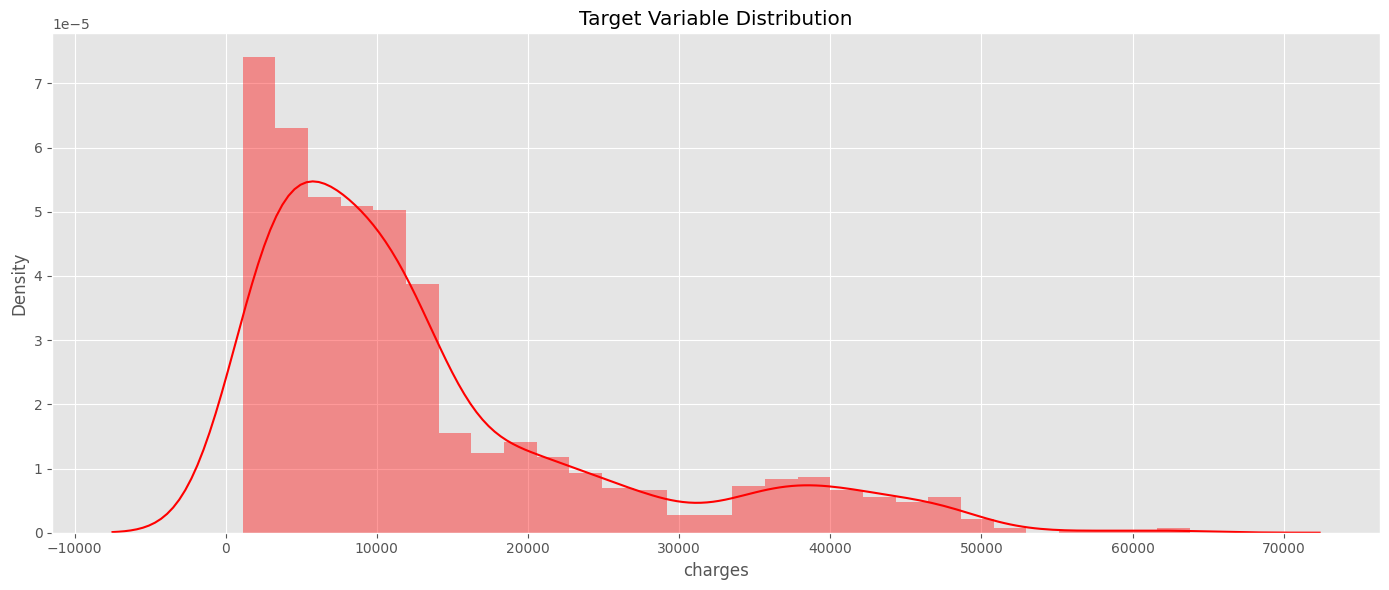

In [73]:
plt.figure(figsize=(14,6))
sns.distplot(df["charges"],color="Red")
plt.title("Target Variable Distribution")
plt.tight_layout()
plt.show()

- The distribution of insurance charges is **right-skewed**, meaning most individuals have lower to moderate medical expenses.
- A small number of individuals have very high insurance costs, creating the long tail on the right side of the distribution.
- This indicates that high-cost cases are relatively rare but significantly increase the overall range of charges.
- The presence of these higher charges suggests that certain factors such as smoking, higher BMI, or age may strongly influence medical expenses.

## 📊Age vs Insurance Charges
- Insurance companies usually charge more for older individuals because the risk of medical issues increases with age.

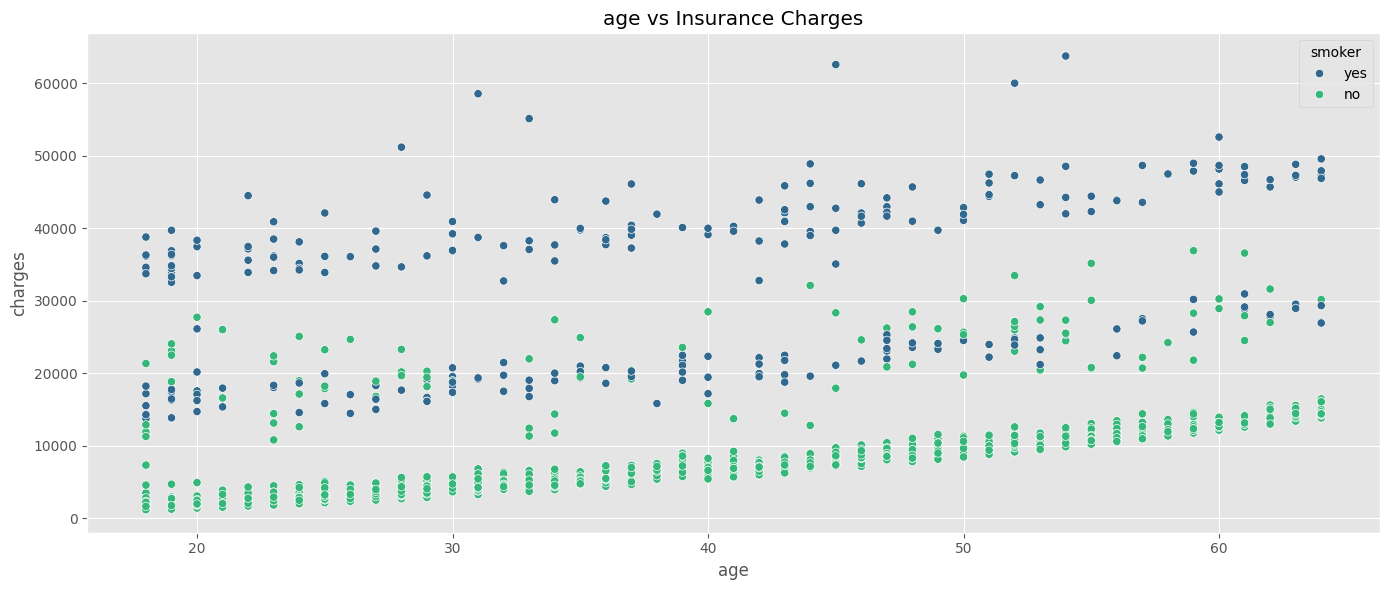

In [74]:
plt.figure(figsize=(14,6))
sns.scatterplot(data=df , x="age" , y="charges", hue="smoker",palette="viridis")
plt.title("age vs Insurance Charges")
plt.tight_layout()
plt.show()

- The scatter plot shows a general upward trend, indicating that insurance charges tend to increase with age.
- Individuals who smoke have significantly higher insurance charges compared to non-smokers across almost all age groups.
- Non-smokers mostly fall within the lower to moderate charge range, while smokers appear in the higher cost region of the plot.
- This suggests that both age and smoking status strongly influence medical insurance costs.

### 📊 BMI vs Insurance Charges
- BMI (Body Mass Index) represents body fat level. Higher BMI is often associated with health risks such as obesity, diabetes, and heart disease, which can increase medical expenses.

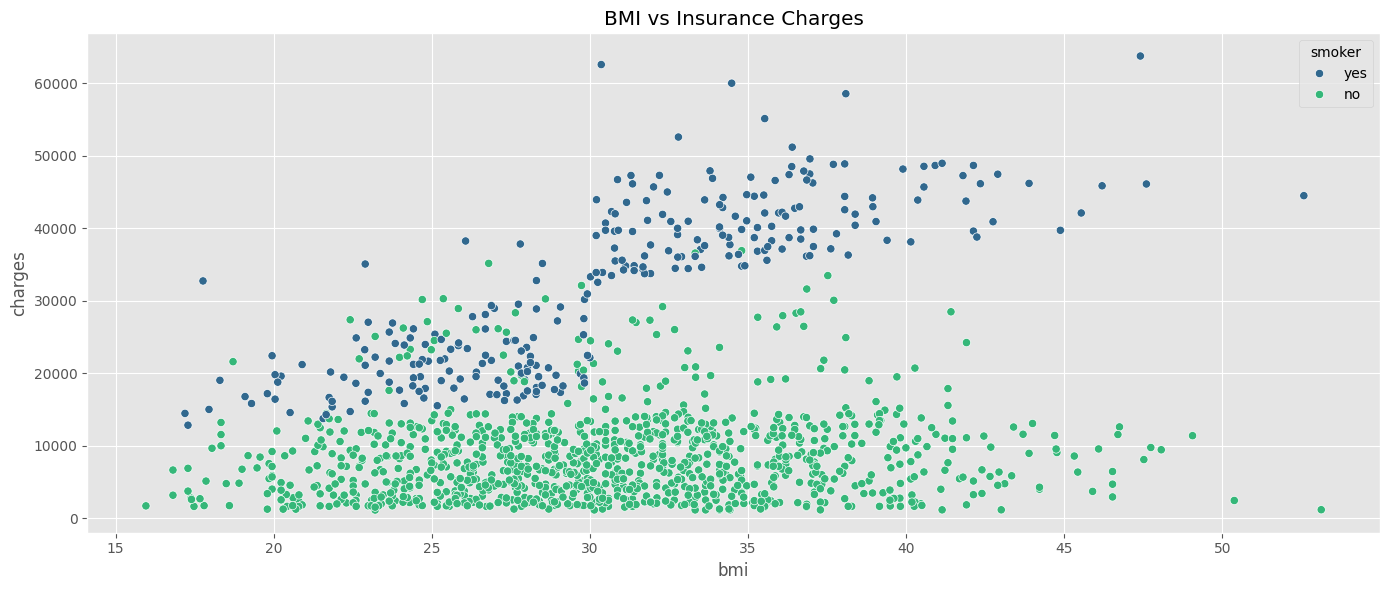

In [75]:
plt.figure(figsize=(14,6))
sns.scatterplot(data=df , x="bmi" , y="charges", hue="smoker",palette="viridis")
plt.title("BMI vs Insurance Charges")
plt.tight_layout()
plt.show()

- The scatter plot shows that BMI alone does not have a very strong linear relationship with insurance charges, as the points are widely scattered.

- However, individuals with higher BMI values tend to appear more frequently in the higher charge range, suggesting that BMI may still contribute to increased medical expenses.
- A clear separation can be observed between smokers and non-smokers, where smokers consistently have much higher insurance charges regardless of BMI level.
- This indicates that smoking status has a stronger impact on insurance charges than BMI, although higher BMI may still increase risk when combined with other factors.

### 📊 Correlation Analysis

### 📊 Smoker vs Insurance Charges
- Smoking increases the risk of many serious health conditions such as heart disease, lung problems, and cancer, which leads to higher medical expenses. Because of this, insurance companies usually charge higher premiums for smokers

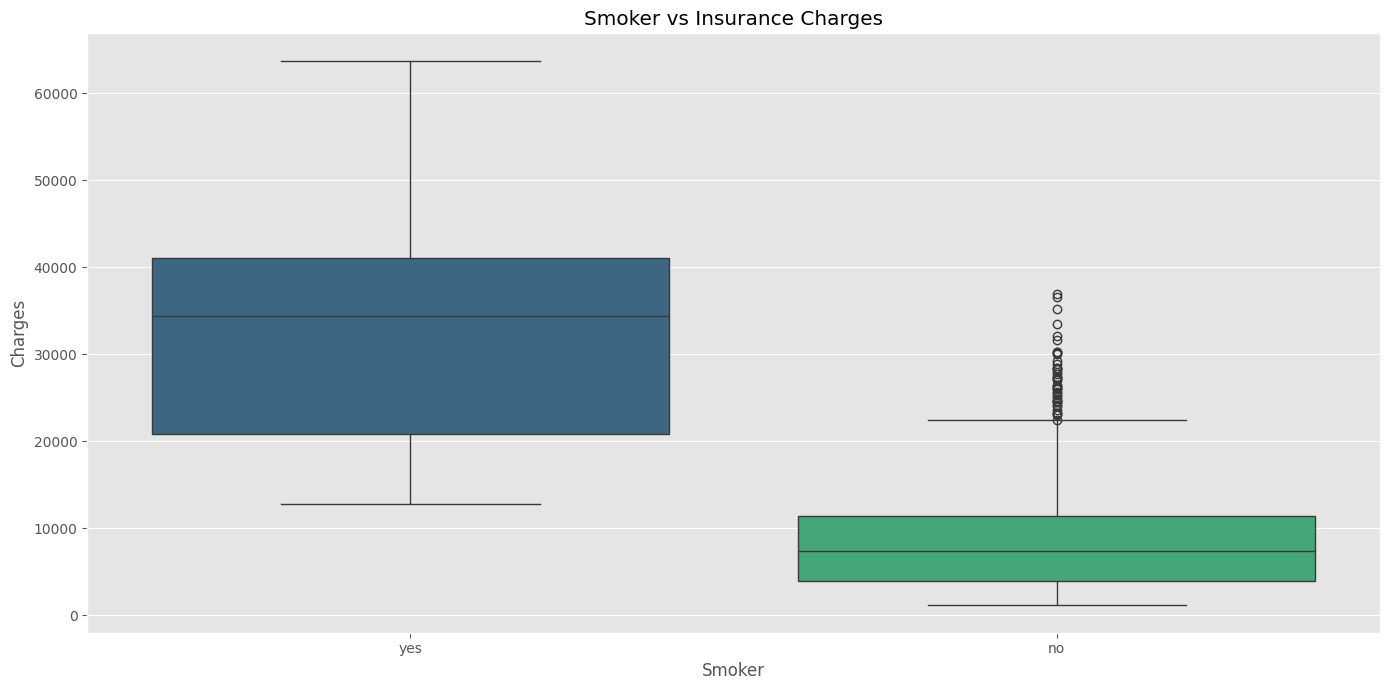

In [76]:
plt.figure(figsize=(14,7))
sns.boxplot(data=df , x="smoker" , y="charges",palette = "viridis")
plt.title("Smoker vs Insurance Charges")
plt.xlabel("Smoker")
plt.ylabel("Charges")
plt.tight_layout()
plt.show()

- The boxplot shows a clear difference in insurance charges between smokers and non-smokers.
- Individuals who smoke have significantly higher median insurance charges compared to non-smokers.
- The spread of charges for smokers is also much wider, indicating higher and more variable medical costs.
- Most non-smokers fall within the lower charge range, while smokers appear predominantly in the higher cost range.
- This suggests that smoking status is one of the strongest factors influencing medical insurance expenses.

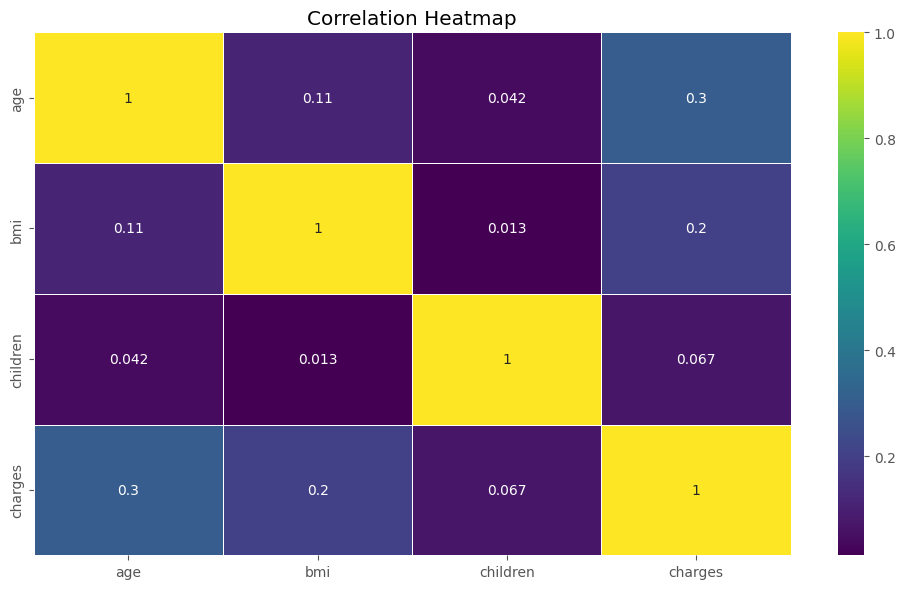

In [77]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="viridis",linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

- The correlation heatmap shows the relationships between numerical variables in the dataset.
- Age has the highest correlation with insurance charges (~0.30), indicating that charges tend to increase with age.
- BMI shows a moderate positive correlation with charges (~0.20), suggesting that higher BMI may slightly increase medical expenses.
- Children has very weak correlation with charges (~0.07), meaning the number of dependents does not significantly affect insurance costs.
- Overall, age and BMI appear to be more relevant numerical predictors of insurance charges, while children has minimal influence.

## OUTLIER DETECTION AND ANALYSIS

In [78]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


- The statistical summary shows that insurance charges have a very wide range, with values going up to around 63,000, indicating the presence of extreme medical costs.
- The BMI values also vary significantly, with a maximum value above 50, suggesting some individuals with unusually high BMI levels.

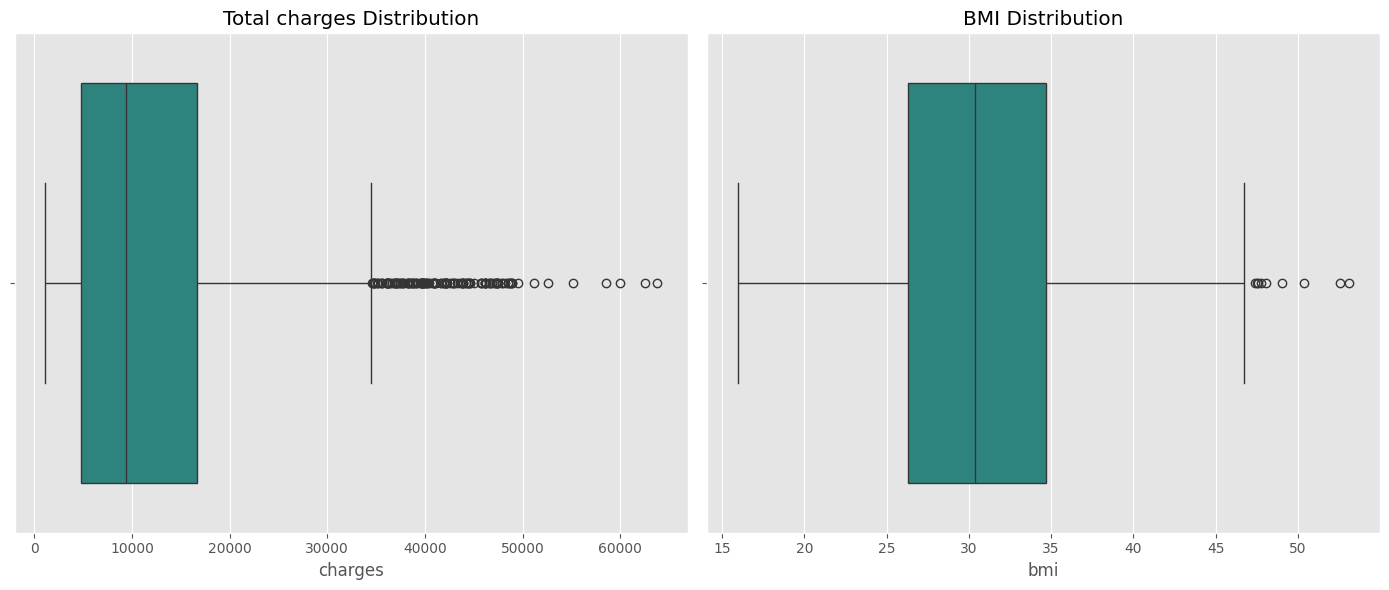

In [79]:
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
sns.boxplot(x=df["charges"],palette="viridis")
plt.title("Total charges Distribution")

plt.subplot(1,2,2)
sns.boxplot(x=df["bmi"],palette="viridis")
plt.title("BMI Distribution")

plt.tight_layout()
plt.show()

- The boxplot for charges shows several extreme values on the higher side, indicating that some individuals have very high medical expenses compared to the majority of the dataset.
- The BMI boxplot also shows a few outliers, representing individuals with unusually high BMI levels.
- These extreme values are likely real-world cases rather than data errors, since both high BMI and high medical costs can naturally occur.
- Therefore, the outliers were retained in the dataset to maintain realistic patterns for insurance cost prediction.

## ⚙️FEATURE ENGINEERING

### 1️⃣ BMI_Category Feature

- #### BMI Category Feature Creation 

In [80]:
def bmi_category(bmi):
    if bmi<18.5:
        return "underweight"
    elif bmi<25:
        return "normal"
    elif bmi<30:
        return "overweight"
    else:
        return "obese"

In [81]:
df["BMI_category"]=df["bmi"].apply(bmi_category)

In [82]:
df.head()


,age,sex,bmi,children,smoker,region,charges,BMI_category
0,19,female,27.900,0,yes,southwest,16884.92400,overweight
1,18,male,33.770,1,no,southeast,1725.55230,obese
2,28,male,33.000,3,no,southeast,4449.46200,obese
3,33,male,22.705,0,no,northwest,21984.47061,normal
4,32,male,28.880,0,no,northwest,3866.85520,overweight


In [83]:
df["BMI_category"].value_counts()

BMI_category
obese          706
overweight     386
normal         225
underweight     20
Name: count, dtype: int64

- A new feature called BMI_category was created by converting the continuous BMI values into health-related categories: **underweight**,**normal**, **overweight**, and **obese**.
- This transformation simplifies the BMI variable and makes it easier to interpret different health risk levels associated with body weight.
- Most individuals in the dataset fall into the overweight and obese categories, while very few belong to the underweight group.
- Categorizing BMI helps in better understanding how different body weight conditions may influence insurance charges and improves the interpretability of the dataset for further analysis and modeling.

- #### BMI Category Feature Analysis

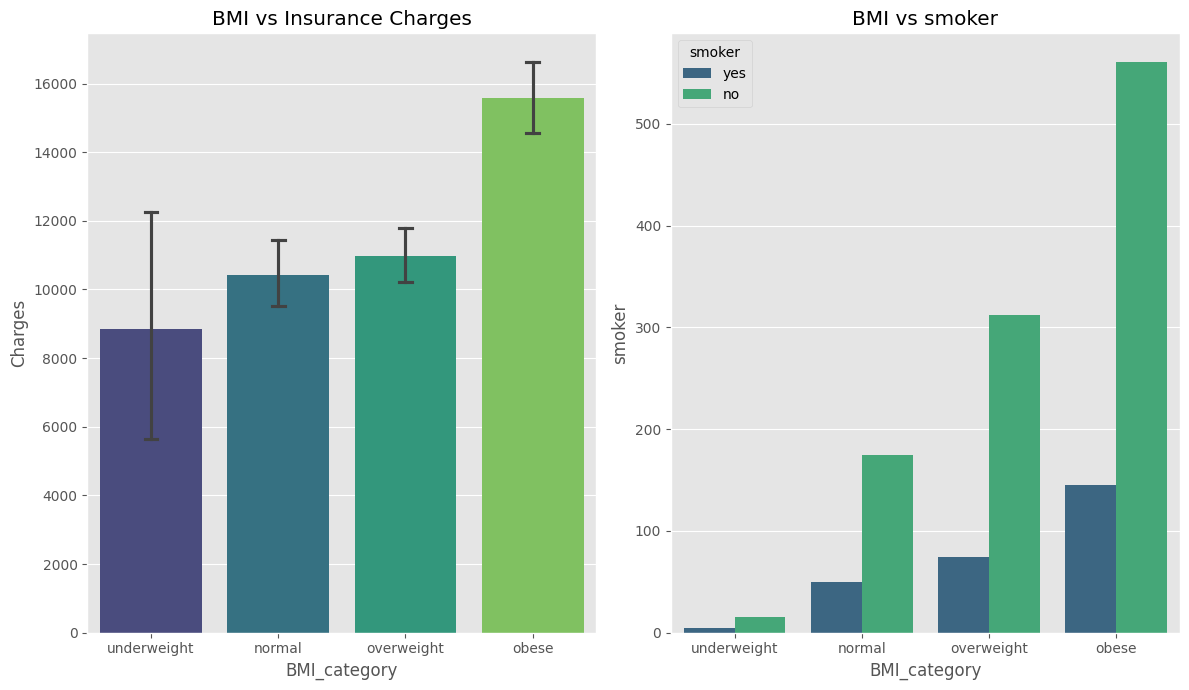

In [84]:
category_oder=["underweight","normal","overweight","obese"]
plt.figure(figsize=(12,7))
plt.subplot(1,2,1)
sns.barplot(data=df , x="BMI_category" , y="charges",palette = "viridis",order=category_oder,capsize=0.1)
plt.title("BMI vs Insurance Charges")
plt.xlabel("BMI_category")
plt.ylabel("Charges")

plt.subplot(1,2,2)
sns.countplot(data=df , x="BMI_category" , hue="smoker",palette = "viridis",order=category_oder)
plt.title("BMI vs smoker")
plt.xlabel("BMI_category")
plt.ylabel("smoker")
plt.tight_layout()
plt.show()

- The bar plot shows that insurance charges increase as BMI category increases. Individuals in the obese category have the highest average insurance costs, while the underweight group has the lowest.
- This suggests that higher BMI levels may be associated with increased medical expenses, likely due to higher health risks.
- The count plot shows that most smokers are concentrated in the overweight and obese BMI categories, while very few smokers appear in the underweight category.
- Since smoking and higher BMI both increase health risks, individuals who are both smokers and obese may have significantly higher insurance charges.

### 2️⃣ Age Group Feature 

- ####  Age Group Feature Creation

In [85]:
def age_group(age):
    if age>=18 and age<=30 :
        return "young"
    elif age>=31 and age<=45 :
        return "adult"
    elif age>=46 and age<=60 :
        return "middle_age"
    else :
        return "senior"

In [86]:
df["age_group"]=df["age"].apply(age_group)

In [87]:
df.head()

,age,sex,bmi,children,smoker,region,charges,BMI_category,age_group
0,19,female,27.900,0,yes,southwest,16884.92400,overweight,young
1,18,male,33.770,1,no,southeast,1725.55230,obese,young
2,28,male,33.000,3,no,southeast,4449.46200,obese,young
3,33,male,22.705,0,no,northwest,21984.47061,normal,adult
4,32,male,28.880,0,no,northwest,3866.85520,overweight,adult


In [88]:
df["age_group"].value_counts()

age_group
young         443
middle_age    409
adult         394
senior         91
Name: count, dtype: int64

- A new feature called age_group was created by categorizing the age variable into different life stages: young, adult, middle_age, and senior.
- This transformation simplifies the interpretation of age-related patterns and helps capture health risk differences across life stages.
- The dataset shows that most individuals belong to the young, adult, and middle_age groups, while relatively fewer observations fall into the senior category.
- Creating age groups helps analyze how insurance charges vary across different age stages and improves the interpretability of the dataset.

- ####  Age Group Feature Analysis

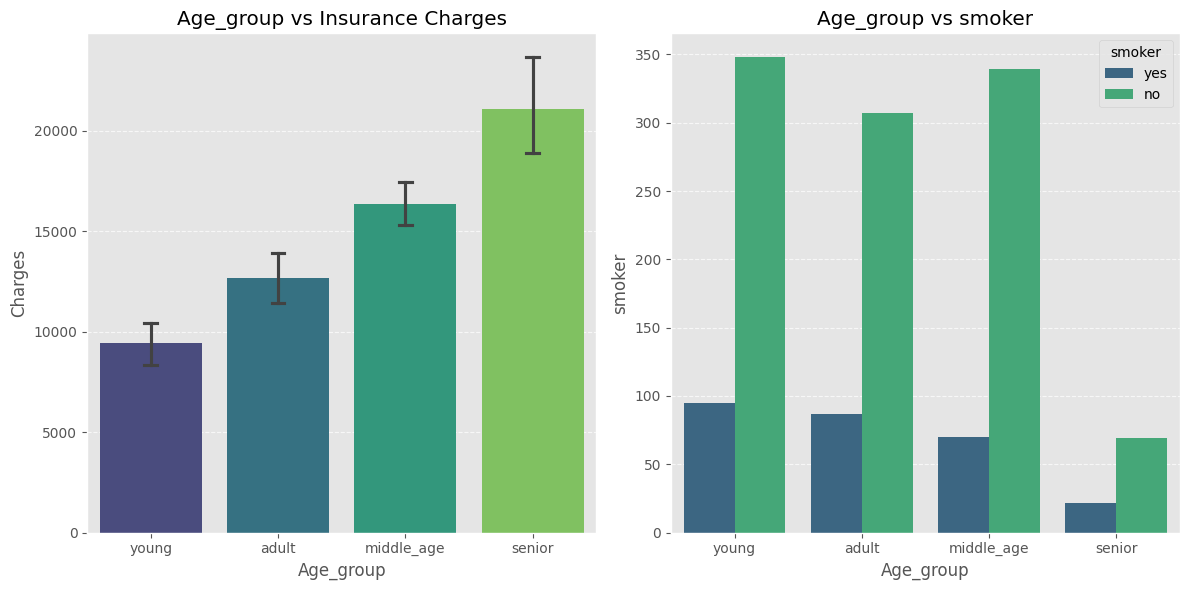

In [89]:
age_group_order=["young","adult","middle_age","senior"]
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
sns.barplot(data=df , x="age_group" , y="charges",palette = "viridis",order=age_group_order,capsize=0.1)
plt.grid(alpha=0.7,axis="y",ls="--")
plt.title("Age_group vs Insurance Charges")
plt.xlabel("Age_group")
plt.ylabel("Charges")

plt.subplot(1,2,2)
sns.countplot(data=df , x="age_group" , hue="smoker",palette = "viridis",order=age_group_order)
plt.title("Age_group vs smoker")
plt.grid(alpha=0.7,axis="y",ls="--")
plt.xlabel("Age_group")
plt.ylabel("smoker")
plt.tight_layout()
plt.show()

- The analysis shows that insurance charges increase as the age group increases, with young individuals having the lowest average charges and middle-age and senior groups having higher costs.
- The smoking distribution across age groups indicates that most individuals are non-smokers, while smokers are present mainly in the young, adult, and middle-age groups.
- Combining these observations suggests that age plays an important role in determining insurance charges, and lifestyle factors such as smoking can further contribute to higher medical risk.
- Overall, individuals belonging to higher age groups and engaging in risky lifestyle habits may have greater insurance expenses.

### 3️⃣ Health Risk Level Feature

- #### Health_risk_level Feature Creation

In [90]:
def health_risk_level(smoker,BMI_category):
    if smoker=="no" and BMI_category in ["underweight","normal"]:
        return "low_risk"
    elif smoker=="yes" and BMI_category in ["overweight","obese"]:
        return "high_risk"
    else:
        return "medium_risk"

In [91]:
df["health_risk_level"]=df.apply( lambda row:health_risk_level(row["smoker"], row["BMI_category"]),axis=1)

In [92]:
df.head()

,age,sex,bmi,children,smoker,region,charges,BMI_category,age_group,health_risk_level
0,19,female,27.900,0,yes,southwest,16884.92400,overweight,young,high_risk
1,18,male,33.770,1,no,southeast,1725.55230,obese,young,medium_risk
2,28,male,33.000,3,no,southeast,4449.46200,obese,young,medium_risk
3,33,male,22.705,0,no,northwest,21984.47061,normal,adult,low_risk
4,32,male,28.880,0,no,northwest,3866.85520,overweight,adult,medium_risk


In [93]:
df["health_risk_level"].value_counts()

health_risk_level
medium_risk    928
high_risk      219
low_risk       190
Name: count, dtype: int64

- A new feature health_risk_level was created by combining smoking status and BMI category, since both factors strongly influence medical risk and insurance costs.
- Individuals who do not smoke and have normal BMI levels were categorized as low risk, while smokers with overweight or obese BMI were categorized as high risk.
- All other combinations were classified as medium risk, representing moderate health conditions.
- This feature helps the model better capture the combined health impact of lifestyle and body condition, which can significantly affect insurance charges.

- #### Health_risk_level Feature Analysis

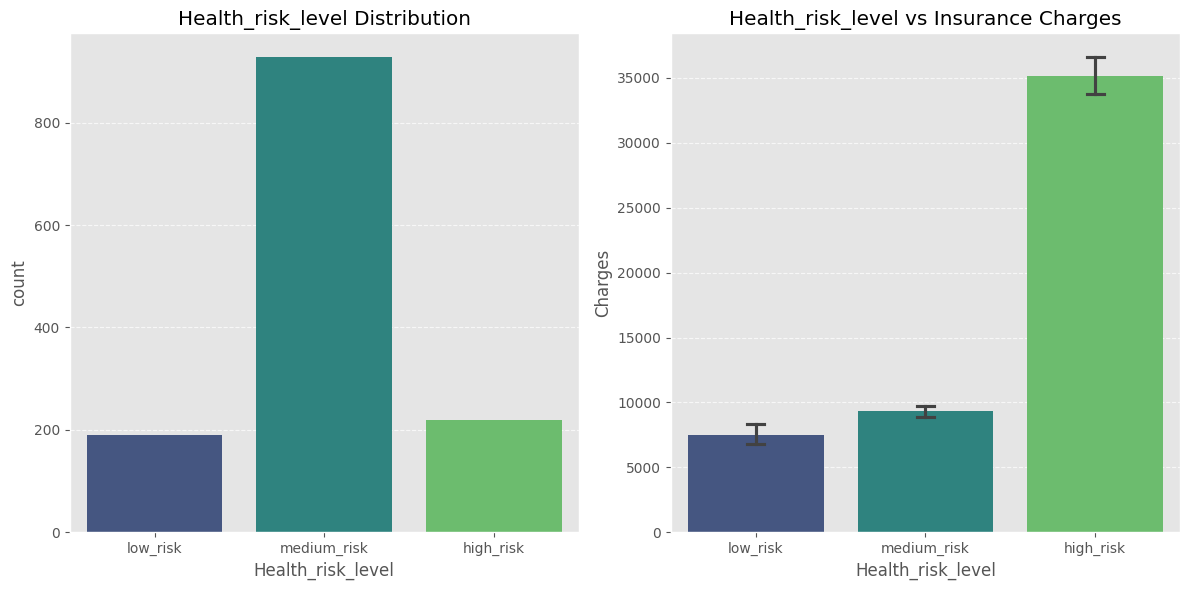

In [94]:
health_risk_level_order=["low_risk","medium_risk","high_risk"]
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
sns.countplot(data=df , x="health_risk_level" ,palette = "viridis",order=health_risk_level_order)
plt.title("Health_risk_level Distribution")
plt.grid(alpha=0.7,axis="y",ls="--")
plt.xlabel("Health_risk_level")
plt.ylabel("count")


plt.subplot(1,2,2)
sns.barplot(data=df , x="health_risk_level" , y="charges",palette = "viridis",order=health_risk_level_order,capsize=0.1)
plt.grid(alpha=0.7,axis="y",ls="--")
plt.title("Health_risk_level vs Insurance Charges")
plt.xlabel("Health_risk_level")
plt.ylabel("Charges")
plt.tight_layout()
plt.show()


- The average insurance charges increase significantly as the health risk level increases. Individuals in the high risk category have the highest
- insurance costs, indicating a strong relationship between health risk factors and medical expenses.
- People in the low risk category show the lowest insurance charges, suggesting that healthier lifestyle patterns lead to lower insurance costs.
- The distribution plot shows that most individuals fall under the medium risk category, while relatively fewer belong to the low risk and high risk groups.
- Overall, this feature clearly captures the combined impact of smoking habits and BMI on insurance charges, making it a meaningful predictor for the model.

## FEATURE AND TARGET VARIABLE SEPERATION

### Preparing Input Features (X) and Target Variable (y)

- In this step, the dataset is divided into features (X) and the target variable (y).
- The column charges represents the insurance cost and is the value that the model will learn to predict. Therefore, it is assigned as the target variable (y).
- All the remaining columns such as age, sex, bmi, children, smoker, region, BMI_category, age_group, and health_risk_level are used as input features (X).

In [95]:
y=df["charges"]

In [96]:
y.head()

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

In [97]:
x=df.drop("charges",axis=1)
x.head()

,age,sex,bmi,children,smoker,region,BMI_category,age_group,health_risk_level
0,19,female,27.900,0,yes,southwest,overweight,young,high_risk
1,18,male,33.770,1,no,southeast,obese,young,medium_risk
2,28,male,33.000,3,no,southeast,obese,young,medium_risk
3,33,male,22.705,0,no,northwest,normal,adult,low_risk
4,32,male,28.880,0,no,northwest,overweight,adult,medium_risk


In [98]:
categorical_columns=["sex","smoker","region","BMI_category","age_group","health_risk_level"]
categorical_columns

['sex', 'smoker', 'region', 'BMI_category', 'age_group', 'health_risk_level']

## Categorical Feature Encoding using One-Hot Encoding

### Transforming Categorical Variables into Numerical Features

- Since machine learning models cannot directly understand categorical text data such as sex, smoker, region, BMI_category, age_group, and health_risk_level, these variables were converted into numerical form using One-Hot Encoding.
- This process creates separate binary columns (0 or 1) for each category, allowing the model to process categorical information effectively.

In [99]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(drop="first", sparse_output=False)
encoded_data = encoder.fit_transform(x[categorical_columns])

In [100]:
encoded_df = pd.DataFrame(encoded_data,columns=encoder.get_feature_names_out(categorical_columns),index=x.index)

In [101]:
encoded_df.head()

,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,BMI_category_obese,BMI_category_overweight,BMI_category_underweight,age_group_middle_age,age_group_senior,age_group_young,health_risk_level_low_risk,health_risk_level_medium_risk
0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [102]:
x = x.drop(columns=categorical_columns)

In [103]:
x.head()

,age,bmi,children
0,19,27.900,0
1,18,33.770,1
2,28,33.000,3
3,33,22.705,0
4,32,28.880,0


In [104]:
x_final=pd.concat([x,encoded_df],axis=1)

In [105]:
x_final.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,BMI_category_obese,BMI_category_overweight,BMI_category_underweight,age_group_middle_age,age_group_senior,age_group_young,health_risk_level_low_risk,health_risk_level_medium_risk
0,19,27.900,0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,18,33.770,1,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,28,33.000,3,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,33,22.705,0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,32,28.880,0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


- After applying One-Hot Encoding, each categorical variable was converted into multiple binary columns. These encoded columns were then combined with the numerical features age, bmi, and children to create the final dataset X_final used for training the machine learning model.

In [106]:
x_final.shape

(1337, 16)

- All categorical variables were successfully transformed into numerical features.
- Each category is represented using binary values (0 or 1).
- The final dataset now contains 16 features for model training.
- This step ensures the Linear Regression model can process categorical information correctly.
- The dataset is now fully prepared for the model training stage.

## TRAIN TEST SPLIT

In [108]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(x_final,y,test_size=0.2,random_state=42)

- The dataset was divided into training and testing sets to evaluate the performance of the machine learning model on unseen data. Approximately 80% of the data was used for training, while 20% was reserved for testing.
- The training set allows the model to learn patterns from the data, while the testing set helps measure how well the model generalizes to new data.

In [110]:
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(1069, 16)
(268, 16)
(1069,)
(268,)


- The dataset was split using 80% training data and 20% testing data.
- Training data contains 1069 samples, which are used to train the model.
- Testing data contains 268 samples, which are used to evaluate model performance.
- This separation helps prevent overfitting and ensures realistic model evaluation.

## Linear Regression Model Training

In [111]:
from sklearn.linear_model import LinearRegression

In [113]:
model=LinearRegression()
model.fit(X_train,Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [114]:
model.coef_

array([   320.48087068,     84.01275514,    689.39279793,   -413.30876929,
        15857.3403293 ,   -712.59869312,   -834.24685251,  -1040.20090389,
         4569.78385288,   1377.41468355,  -1854.34510815,    103.63333487,
         -267.29272963,   2464.86275468,  -5786.91042231, -10230.71802111])

In [115]:
model.intercept_

np.float64(-745.3632408868652)

-The intercept represents the baseline value of insurance charges when all feature values are zero. In this model, the intercept is negative, which indicates that the regression line starts below zero on the y-axis. This is mathematically acceptable since feature values such as age and BMI cannot realistically be zero in the dataset.

## Model Prediction

### Predicting Insurance Charges Using the Trained Model

- After training the Linear Regression model, predictions were generated using the test dataset (X_test). The model uses the learned regression equation and feature coefficients to estimate the insurance charges for unseen data points.
- These predicted values represent the model's estimation of insurance costs based on the given input features.

In [116]:
y_pred = model.predict(X_test)

In [117]:
y_pred[:5]

array([10753.16074791,  6028.23824555, 14454.24412716, 33448.13751324,
        6885.08922607])

- Predictions were generated for 268 unseen test samples.
- The model applies the learned regression equation to estimate insurance charges.
- The output y_pred contains the predicted insurance charges for the test dataset.
- These predictions will now be compared with the actual values (y_test) to evaluate model performance.